<a href="https://colab.research.google.com/github/Juan-Zavanela/fishmorph-svm/blob/main/FishMorph_Order.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importando bibliotecas
!pip install kagglehub

import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report


In [2]:
# Carregamento do dataset

path = kagglehub.dataset_download('menegidio/fishmorph-dataset')
print(os.listdir(path))

df = pd. read_csv(os.path.join(path,"FISHMORPH_Order_Dataset.csv"))

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
['FISHMORPH_Order_Dataset.csv', 'FISHMORPH_Family_Dataset.csv']


In [3]:
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


In [4]:
# Tratamento de dados

print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Order   8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB
None
               MBl          BEl          VEp          REs          OGp  \
count  8342.000000  8342.000000  8342.000000  8342.000000  8342.000000   
mean     22.004517     4.452438     0.549087     0.391665     0.381768   
std      33.612007     2.338235     0.094883     0.132814     0.194352   
min       1.200000     1.033084     0.159248     0.00000

In [5]:
# Excluindo valores duplicados

df=df.drop_duplicates()

Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Salmoniformes           92
Atheriniformes          71
Scorpaeniformes         70
Osmeriformes            69
Synbranchiformes        48
Beloniformes            33
Tetraodontiformes       31
Pleuronectiformes       28
Acipenseriformes        23
Mugiliformes            18
Syngnathiformes         16
Anguilliformes          16
Gasterosteiformes       13
Gonorynchiformes        10
Esociformes             10
Polypteriformes          9
Lepisosteiformes         6
Percopsiformes           6
Elopiformes              5
Batrachoidiformes        4
Gadiformes               3
Gobiesociformes          3
Amiiformes               1
Ophidiiformes            1
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

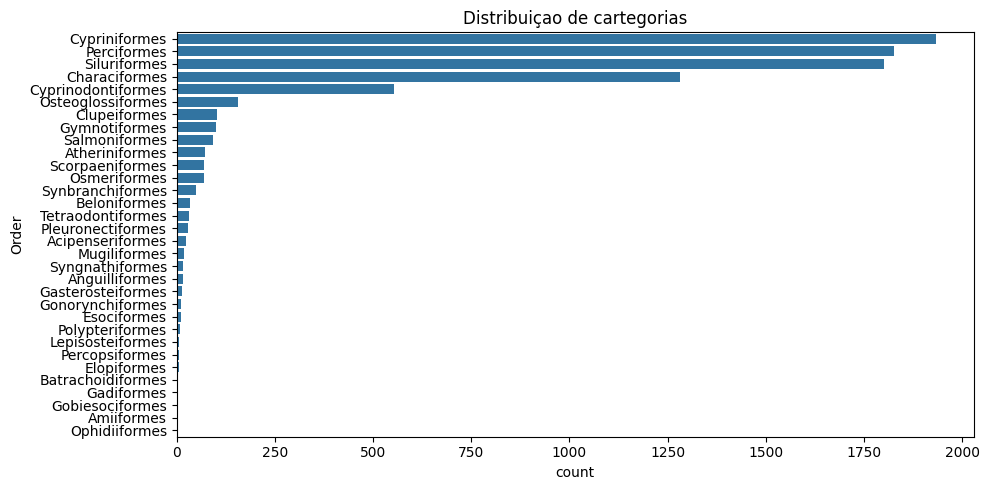

In [6]:
#Distribuiçao de Categorias

alvo = "Order"
print(df[alvo].value_counts())

plt.figure(figsize = (10, 5))
sns.countplot(y  = df[alvo], order = df[alvo].value_counts().index)
plt.title("Distribuiçao de cartegorias")
plt.tight_layout()
plt.show

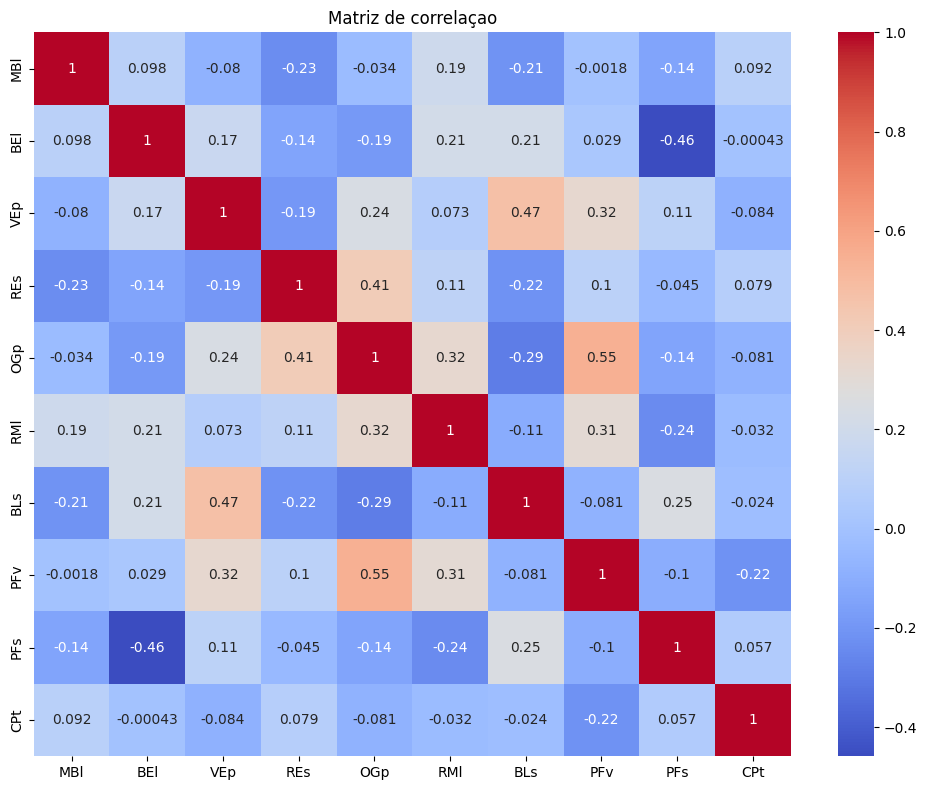

In [7]:
# Matriz de correlaçao

plt.figure (figsize = (10 , 8))
sns.heatmap(df.select_dtypes(include =  "number").corr(), annot = True , cmap = "coolwarm")
plt.title("Matriz de correlaçao")
plt.tight_layout()
plt.show()

In [8]:
# Removendo ordens raras( com apenas um registro no dataset)

contagem = df["Order"].value_counts()
classes_validas = contagem[contagem >= 20].index
print("Ordens antes:", len(contagem), "| depois:", len(classes_validas))

df = df[df["Order"].isin(classes_validas)]

#Separar X e y

X = df.drop("Order", axis = 1).select_dtypes(include="number")

y = df["Order"]

print(X,y)

Ordens antes: 32 | depois: 17
        MBl       BEl       VEp       REs       OGp       RMl       BLs  \
0     130.0  4.579113  0.622642  0.375019  0.622642  0.868659  0.484981   
1      11.5  2.796068  0.650700  0.353780  0.509800  0.411157  0.722461   
2       6.6  4.564329  0.518187  0.312002  0.203985  0.413221  0.591495   
3      10.9  4.390422  0.548247  0.244804  0.168959  0.324728  0.642991   
4      18.9  4.410271  0.542353  0.292058  0.183790  0.398567  0.685672   
...     ...       ...       ...       ...       ...       ...       ...   
8337   22.0  8.160515  0.742393  0.394320  0.307719  0.332283  0.793826   
8338   50.0  5.241134  0.600061  0.377792  0.293883  0.301585  0.617588   
8339    4.0  3.159920  0.453558  0.560501  0.533168  0.175106  0.470270   
8340  140.0  4.165031  0.545773  0.115646  0.471200  0.483810  0.498305   
8341  140.0  4.420704  0.600544  0.145919  0.422607  0.458131  0.476710   

           PFv       PFs       CPt  
0     0.273585  0.144108  3.3489

In [9]:
print(y.value_counts())

Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Salmoniformes           92
Atheriniformes          71
Scorpaeniformes         70
Osmeriformes            69
Synbranchiformes        48
Beloniformes            33
Tetraodontiformes       31
Pleuronectiformes       28
Acipenseriformes        23
Name: count, dtype: int64


In [10]:
#Divisão de treino e teste

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [ ]:
# GridSearchCV com Cross Validation( 4 valores por Hiperparametro)

pipe = Pipeline([
    ("scaller", StandardScaler()),
    ("svm", SVC(cache_size=1000))
])

param = {
    "svm__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1,1]
}

cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)
grid = GridSearchCV (pipe, param, cv=cv, scoring = "accuracy", n_jobs = -1, verbose =1 )
grid.fit(X_train, y_train)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


In [ ]:
# Exibindo melhores modelos, parametros e acuracia


print("Modelo: ",grid.best_estimator_.named_steps["svm"])
print("Melhores parametros: ", grid.best_params_)
print("Acuracia media(validaçao cruzada): ", round(grid.best_score_, 4))

y_pred = grid.predct(X_test)
print("Acuracia no teste: ", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

In [ ]:
# Matriz de confusão

fig, ax = plt.subplots(figsize = (10, 8))
ConfusionMatrixDisplay.from_predction(y_test, y_test, ax = ax , xticks_rotation = 90, cmap = "Blues")
plt.title( "Matriz de Comfusçao - SVM")
plt.tight_layout()
plt.show()